# L17 · Autoencoders for Single-Cell Expression

*Companion notebook for Lecture 17 — Autoencoders and Representation Learning (CS184A/284A, AI in Biology and Medicine).*

**Learning objectives**

1. Build and train a PyTorch autoencoder (encoder $f_{\phi}$, bottleneck $\mathbf z\in\mathbb R^k$, decoder $g_{\theta}$) on PBMC3k single-cell expression, and sweep the latent dimension $k$.
2. Evaluate a representation the honest way: reconstruction of **held-out** cells, 15-NN label transfer and a linear probe, always against PCA.
3. Check numerically that a **linear** autoencoder trained with squared error finds the PCA subspace (principal angles).
4. Use a **denoising** autoencoder to impute hidden expression values, and compare it with simple baselines.
5. See why a plain autoencoder cannot generate new cells (empty regions of the latent space), the motivation for L18.

Notation (as on the slides): $n$ cells, $d$ genes, $\mathbf X\in\mathbb R^{n\times d}$ with cells in rows;
$\mathbf z = f_{\phi}(\mathbf x)$, $\hat{\mathbf x} = g_{\theta}(\mathbf z)$; loss $\mathcal L$ = mean squared error per entry.

**Runtime:** about 5–6 minutes on a laptop CPU (4 threads). To stay within that budget the latent-dimension sweep uses
**one seed** (the deck averages 3 seeds) and training stops once the validation loss has not improved for 50 epochs;
see §5 for how the numbers compare with the slides. The optional convolutional autoencoder on BloodMNIST (§11) runs
only when a GPU/MPS device is available.

In [1]:
import os
# numba (used by UMAP / Scanpy) and PyTorch ship different OpenMP runtimes; on macOS the combination can crash the
# kernel. The 'workqueue' threading layer avoids the conflict.
os.environ.setdefault("NUMBA_THREADING_LAYER", "workqueue")
import sys, pathlib, time, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # course_utils.py lives in applications/
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from scipy.linalg import subspace_angles
from sklearn.decomposition import PCA
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.preprocessing import StandardScaler
from course_utils import seed_everything, plot_style, device, DATA, PALETTE

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
rng = seed_everything(0)
plot_style()
dev = device()
print("device:", dev, "| torch threads:", torch.get_num_threads())
T0 = time.time()

KS = [2, 4, 8, 16, 32, 64]   # latent dimensions in the sweep
SEEDS = [0]                  # the deck uses [0, 1, 2] (mean ± SD); 3 seeds triple the sweep time
EPOCHS = 150                 # maximum epochs; the best-validation weights are kept
PATIENCE = 50                # stop when validation MSE has not improved for this many epochs (None = run all epochs)
HID = (256, 128)             # hidden widths of encoder (mirrored in the decoder)
MASK_FRAC = 0.10             # fraction of nonzero entries hidden in the imputation experiment (§8)
K_IMP = 16                   # latent dimension of the imputation autoencoders
K_LIN = 10                   # latent dimension for the linear AE vs PCA check (§7)
RUN_CONV = dev.type != "cpu" # optional BloodMNIST convolutional AE (§11): GPU/MPS only

device: cuda | torch threads: 4


## 1. Dataset: PBMC3k single-cell RNA-seq

**What is measured.** Droplet single-cell RNA-seq (10x Genomics): the number of RNA molecules (UMIs) of each gene
captured from individual peripheral blood mononuclear cells (PBMCs) of one healthy donor. **One sample = one cell.**
Only a fraction of each cell's mRNA is captured, so the matrix is sparse and noisy (many zeros are *dropouts*).

- **Input** $\mathbf x$: log-normalized expression of the $d = 1{,}838$ highly variable genes (as in L15, but **not**
  z-scored, so the MSE is in log-expression units).
- **Target**: the input itself — an autoencoder needs no labels.
- **Labels (evaluation only)**: 8 marker-based cell types, named from Leiden clusters of the standard L15 pipeline.
- **Why it matters**: low-dimensional codes of cells drive clustering, maps and imputation in every single-cell pipeline.

Source: 10x Genomics public data set "3k PBMCs from a healthy donor" (freely available from 10x Genomics),
loaded with `scanpy.datasets.pbmc3k()` (Wolf et al., *Genome Biology* 2018; 10x technology: Zheng et al.,
*Nature Communications* 2017). The file (≈ 6 MB) is cached in `applications/data/`.

Pipeline (identical to L15 and the lecture): QC (200–2,500 genes, < 5% mitochondrial counts) → normalize each cell to
10,000 counts → $\log(1+x)$ → highly variable genes. For the cell-type labels and the UMAP only: z-score → PCA (50) →
kNN graph (10 neighbors, 40 PCs) → Leiden (resolution 1.0) → name clusters by marker genes.

In [2]:
import scanpy as sc
sc.settings.datasetdir = DATA
sc.settings.verbosity = 0
a = sc.datasets.pbmc3k()
n_raw, d_raw = a.shape
a.var["mt"] = a.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(a, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)
sc.pp.filter_cells(a, min_genes=200)
sc.pp.filter_genes(a, min_cells=3)
a = a[(a.obs.n_genes_by_counts < 2500) & (a.obs.pct_counts_mt < 5)].copy()
a.layers["counts"] = a.X.copy()                            # raw UMI counts (for the Poisson try)
lib = np.asarray(a.X.sum(1)).ravel()                        # library size = total UMIs per cell
sc.pp.normalize_total(a, target_sum=1e4)
sc.pp.log1p(a)
a.raw = a
sc.pp.highly_variable_genes(a, min_mean=0.0125, max_mean=3, min_disp=0.5)
a = a[:, a.var.highly_variable].copy()
X = np.asarray(a.X.todense(), dtype=np.float32)            # log-normalized HVGs: the autoencoder input
Xcounts = np.asarray(a.layers["counts"].todense(), dtype=np.float32)
genes = np.array(a.var_names, dtype=str)

# labels and UMAP from the standard (PCA-based) pipeline
sc.pp.scale(a, max_value=10)
sc.tl.pca(a, n_comps=50, svd_solver="arpack", random_state=0)
sc.pp.neighbors(a, n_neighbors=10, n_pcs=40, random_state=0)
sc.tl.leiden(a, resolution=1.0, random_state=0, flavor="igraph", n_iterations=2, directed=False)
sc.tl.umap(a, random_state=0)
MARKERS = {"CD4 T": ["IL7R", "CCR7"], "CD8 T": ["CD8A", "CD8B"], "NK": ["GNLY", "NKG7"], "B": ["MS4A1", "CD79A"],
           "CD14 mono": ["CD14", "LYZ"], "FCGR3A mono": ["FCGR3A", "MS4A7"], "DC": ["FCER1A", "CST3"],
           "Platelet": ["PPBP"]}
CTYPES = list(MARKERS)
R = a.raw.to_adata()
M = pd.DataFrame({ct: np.asarray(R[:, gs].X.todense()).mean(1) for ct, gs in MARKERS.items()})
M["cl"] = a.obs.leiden.values
G = M.groupby("cl", observed=True).mean()
mapping = ((G - G.mean()) / G.std()).idxmax(axis=1).to_dict()
ctype = a.obs.leiden.map(mapping).astype(str).values
leiden = a.obs.leiden.values.astype(int)
UMAP_L15 = a.obsm["X_umap"]
CCOL = dict(zip(CTYPES, [PALETTE[0], PALETTE[4], PALETTE[2], PALETTE[1], PALETTE[5], PALETTE[3], "#7F4F24", "#1F2933"]))
n, d = X.shape
print(f"raw: {n_raw:,} cells x {d_raw:,} genes -> after QC and HVG selection: n = {n:,} cells, d = {d:,} genes")
print(f"{leiden.max() + 1} Leiden clusters ->", pd.Series(ctype).value_counts().to_dict())

raw: 2,700 cells x 32,738 genes -> after QC and HVG selection: n = 2,638 cells, d = 1,838 genes
9 Leiden clusters -> {'CD4 T': 1173, 'CD14 mono': 427, 'B': 339, 'CD8 T': 275, 'FCGR3A mono': 211, 'NK': 163, 'DC': 37, 'Platelet': 13}


## 2. Exploration: a sparse, noisy matrix

raw counts of the HVGs: 91.6% zeros; median 2,213 UMIs per cell
log-normalized X: 8.4% nonzero entries, values 0 to 7.15


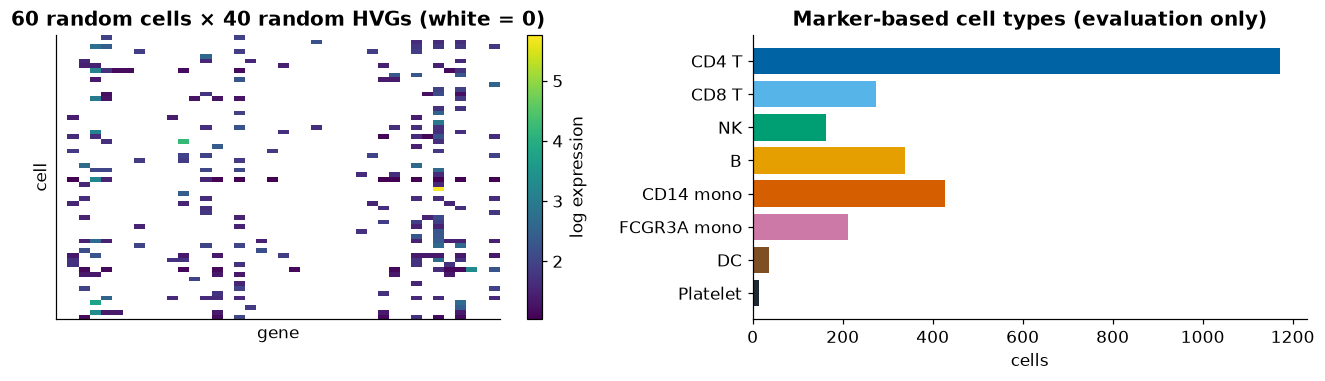

In [3]:
print(f"raw counts of the HVGs: {100 * (Xcounts == 0).mean():.1f}% zeros; median {np.median(lib):,.0f} UMIs per cell")
print(f"log-normalized X: {100 * (X > 0).mean():.1f}% nonzero entries, values 0 to {X.max():.2f}")
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
blk = X[rng.choice(n, 60, replace=False)][:, rng.choice(d, 40, replace=False)]
im = axes[0].imshow(np.ma.masked_equal(blk, 0), aspect="auto", cmap="viridis", interpolation="nearest")
axes[0].set(title="60 random cells × 40 random HVGs (white = 0)", xlabel="gene", ylabel="cell", xticks=[], yticks=[])
plt.colorbar(im, ax=axes[0], label="log expression")
vc = pd.Series(ctype).value_counts().reindex(CTYPES)
axes[1].barh(CTYPES[::-1], vc.values[::-1], color=[CCOL[c] for c in CTYPES[::-1]])
axes[1].set(xlabel="cells", title="Marker-based cell types (evaluation only)")
plt.tight_layout(); plt.show()

Platelets and dendritic cells are rare, so accuracies are dominated by T cells and monocytes. Note that the labels
come from a **PCA-based** pipeline, which slightly favors PCA in every comparison below.

## 3. Preprocessing: a stratified train/test split

All models (PCA and autoencoders) are fit on the training cells only; every metric is computed on held-out cells.
The autoencoder additionally holds out a random 10% of its training cells for early stopping.

In [4]:
tr, te = train_test_split(np.arange(n), test_size=0.2, stratify=ctype, random_state=0)
print(f"train {len(tr):,} cells, test {len(te):,} cells")

train 2,110 cells, test 528 cells


## 4. Model: a fully connected autoencoder

Encoder $d \to 256 \to 128 \to k$ and a mirrored decoder $k \to 128 \to 256 \to d$, ReLU in between, linear output
(log expression is continuous, so MSE and a linear output layer are natural). `linear=True` gives the linear AE of §7.

In [5]:
def make_ae(d, k, hid=HID, linear=False):
    class AE(nn.Module):
        def __init__(self):
            super().__init__()
            if linear:
                self.enc, self.dec = nn.Linear(d, k), nn.Linear(k, d)
            else:
                h1, h2 = hid
                self.enc = nn.Sequential(nn.Linear(d, h1), nn.ReLU(), nn.Linear(h1, h2), nn.ReLU(), nn.Linear(h2, k))
                self.dec = nn.Sequential(nn.Linear(k, h2), nn.ReLU(), nn.Linear(h2, h1), nn.ReLU(), nn.Linear(h1, d))

        def forward(self, x):
            z = self.enc(x)
            return self.dec(z), z
    return AE()


def n_params(m):
    return sum(p.numel() for p in m.parameters())


for k in (2, 10, 16):
    print(f"k = {k:2d}: {n_params(make_ae(d, k)):,} parameters")

k =  2: 1,009,712 parameters
k = 10: 1,011,768 parameters
k = 16: 1,013,310 parameters


## 5. Training

Adam (learning rate $10^{-3}$), batch 128, up to 150 epochs, MSE per entry. Every 5 epochs we compute the MSE on the
10% validation cells and keep the weights with the lowest value (early stopping). `mask_p > 0` turns the model into a
**denoising** AE (masking noise: each input entry set to 0 with probability `mask_p`; the target stays uncorrupted).
The extra arguments `loss="poisson"`, `Y`, `offset` and `l1` are used only in *Try it yourself*.

In [6]:
def train_ae(Xtr, k, seed=0, epochs=EPOCHS, mask_p=0.0, lr=1e-3, bs=128, linear=False, val_frac=0.1, every=5,
             patience=PATIENCE, hid=HID, loss="mse", Y=None, offset=None, l1=0.0):
    """Train an AE on the rows of Xtr; return (model with best-validation weights, history).
    loss="poisson": decoder output = log rate per 10^4 UMIs; Y = raw counts, offset = log(library size / 10^4)."""
    torch.manual_seed(seed)
    g = torch.Generator().manual_seed(seed)
    perm0 = np.random.default_rng(seed).permutation(len(Xtr))
    nv = int(val_frac * len(Xtr))
    Yall = Xtr if Y is None else Y
    off = np.zeros((len(Xtr), 1), np.float32) if offset is None else np.asarray(offset, np.float32).reshape(-1, 1)
    X_, Xv = torch.tensor(Xtr[perm0[nv:]]), torch.tensor(Xtr[perm0[:nv]])
    Y_, Yv = torch.tensor(Yall[perm0[nv:]]), torch.tensor(Yall[perm0[:nv]])
    O_, Ov = torch.tensor(off[perm0[nv:]]), torch.tensor(off[perm0[:nv]])

    def rec_loss(xh, y, o):
        if loss == "poisson":                       # negative Poisson log-likelihood (up to a constant)
            eta = xh + o
            return (torch.exp(eta) - y * eta).mean()
        return ((xh - y) ** 2).mean()

    m = make_ae(X_.shape[1], k, hid=hid, linear=linear)
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    hist = dict(train=[], val=[], ep=[])
    best, state, since = np.inf, None, 0
    for ep in range(epochs):
        m.train()
        perm = torch.randperm(len(X_), generator=g)
        tot = 0.0
        for i in range(0, len(X_), bs):
            b = perm[i:i + bs]
            xb = X_[b]
            xin = xb * (torch.rand(xb.shape, generator=g) >= mask_p) if mask_p > 0 else xb
            xh, z = m(xin)
            L = rec_loss(xh, Y_[b], O_[b])
            if l1 > 0:
                L_total = L + l1 * z.abs().sum(1).mean()
            else:
                L_total = L
            opt.zero_grad()
            L_total.backward()
            opt.step()
            tot += L.item() * len(xb)
        if (ep + 1) % every == 0:
            m.eval()
            with torch.no_grad():
                v = rec_loss(m(Xv)[0], Yv, Ov).item()
            hist["train"].append(tot / len(X_)); hist["val"].append(v); hist["ep"].append(ep + 1)
            if v < best:
                best, state, since = v, {a_: b_.clone() for a_, b_ in m.state_dict().items()}, 0
            else:
                since += every
                if patience is not None and since >= patience:
                    break
    m.load_state_dict(state)
    hist["best_ep"] = hist["ep"][int(np.argmin(hist["val"]))]
    m.eval()
    return m, hist


def ae_apply(m, X):
    with torch.no_grad():
        xh, z = m(torch.tensor(X))
    return xh.numpy(), z.numpy()


def eval_embedding(Ztr, Zte, ytr, yte):
    """kNN label transfer (15 neighbors) and linear probe (logistic regression on standardized z), held-out accuracy."""
    knn = KNeighborsClassifier(15).fit(Ztr, ytr).score(Zte, yte)
    s = StandardScaler().fit(Ztr)
    probe = LogisticRegression(max_iter=3000, C=1.0).fit(s.transform(Ztr), ytr).score(s.transform(Zte), yte)
    return float(knn), float(probe)

First one model with a 2-dimensional code, to see the learning curves.

k = 2: 18 s, best validation epoch 50 (stopped after 100)


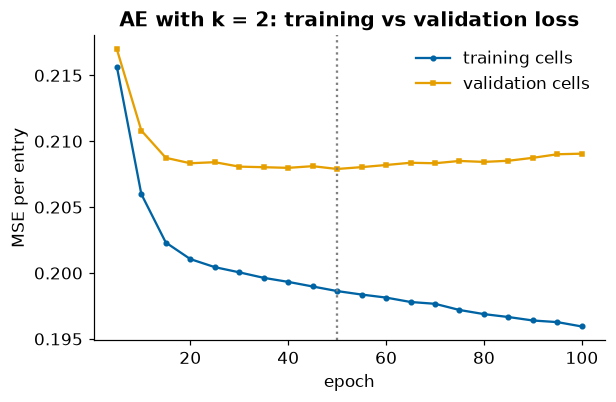

In [7]:
t = time.time()
m2, h2 = train_ae(X[tr], 2, seed=0)
print(f"k = 2: {time.time() - t:.0f} s, best validation epoch {h2['best_ep']} (stopped after {h2['ep'][-1]})")
plt.figure(figsize=(6, 3.6))
plt.plot(h2["ep"], h2["train"], "o-", ms=3, label="training cells")
plt.plot(h2["ep"], h2["val"], "s-", ms=3, label="validation cells")
plt.axvline(h2["best_ep"], color="gray", ls=":")
plt.xlabel("epoch"); plt.ylabel("MSE per entry"); plt.title("AE with k = 2: training vs validation loss")
plt.legend(); plt.show()

The training loss keeps falling while the validation loss turns up after a few dozen epochs: with ~1,900 noisy
cells and ~1 million weights, the network soon starts to memorize noise. Early stopping keeps the best epoch.

### Latent-dimension sweep: autoencoder vs PCA

For each $k$: PCA with $k$ components and an AE with a $k$-dimensional code, both fit on the training cells.
We report the MSE per entry on the **test** cells, and 15-NN / linear-probe cell-type accuracy on the test cells
using the codes. Baselines: predicting every gene's training mean (MSE), and using all 1,838 genes as the "code".

In [8]:
res_pca, res_ae, models = {}, {}, {}
raw_acc = eval_embedding(X[tr], X[te], ctype[tr], ctype[te])
mean_mse = float(((X[te] - X[tr].mean(0)) ** 2).mean())
t = time.time()
for k in KS:
    p = PCA(k, svd_solver="full", random_state=0).fit(X[tr])
    Ztr, Zte = p.transform(X[tr]), p.transform(X[te])
    res_pca[k] = dict(mse=float(((p.inverse_transform(Zte) - X[te]) ** 2).mean()),
                      **dict(zip(["knn", "probe"], eval_embedding(Ztr, Zte, ctype[tr], ctype[te]))))
    rows = []
    for s in SEEDS:
        m, h = (m2, h2) if (k == 2 and s == 0) else train_ae(X[tr], k, seed=s)
        xh, Zte = ae_apply(m, X[te]); _, Ztr = ae_apply(m, X[tr])
        rows.append(dict(mse=float(((xh - X[te]) ** 2).mean()), best_ep=h["best_ep"],
                         **dict(zip(["knn", "probe"], eval_embedding(Ztr, Zte, ctype[tr], ctype[te])))))
        if s == 0:
            models[k] = m
    res_ae[k] = pd.DataFrame(rows).mean().to_dict() | {"knn_sd": pd.DataFrame(rows)["knn"].std(ddof=0)}
print(f"sweep: {time.time() - t:.0f} s")
tab = pd.DataFrame({"AE MSE": [res_ae[k]["mse"] for k in KS], "PCA MSE": [res_pca[k]["mse"] for k in KS],
                    "AE 15-NN": [res_ae[k]["knn"] for k in KS], "PCA 15-NN": [res_pca[k]["knn"] for k in KS],
                    "AE probe": [res_ae[k]["probe"] for k in KS], "PCA probe": [res_pca[k]["probe"] for k in KS],
                    "AE best epoch": [res_ae[k]["best_ep"] for k in KS]}, index=pd.Index(KS, name="k"))
print(tab.round(3).to_string())
print(f"baselines: gene-mean MSE {mean_mse:.3f}; all {d:,} genes: 15-NN {raw_acc[0]:.3f}, probe {raw_acc[1]:.3f}")

sweep: 66 s
    AE MSE  PCA MSE  AE 15-NN  PCA 15-NN  AE probe  PCA probe  AE best epoch
k                                                                           
2    0.203    0.210     0.924      0.852     0.915      0.860           50.0
4    0.201    0.203     0.947      0.953     0.945      0.941           25.0
8    0.200    0.198     0.955      0.958     0.955      0.964           25.0
16   0.199    0.194     0.945      0.966     0.941      0.968           25.0
32   0.197    0.187     0.947      0.964     0.958      0.964           35.0
64   0.196    0.175     0.949      0.956     0.958      0.955           35.0
baselines: gene-mean MSE 0.238; all 1,838 genes: 15-NN 0.833, probe 0.956


## 6. Evaluation

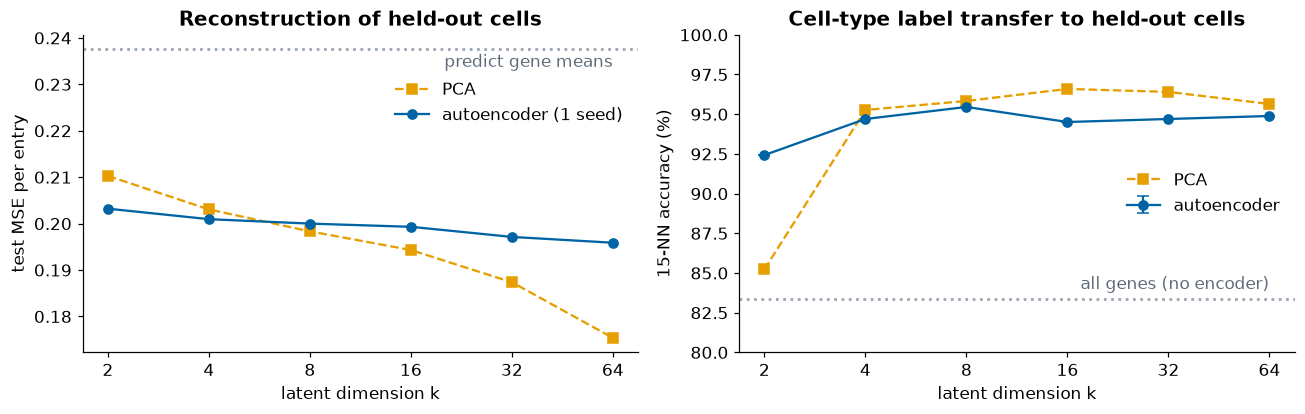

k = 2 : AE test MSE 0.203 vs PCA 0.210; 15-NN 92% vs 85%
k = 64: AE test MSE 0.196 vs PCA 0.175


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.9))
ax = axes[0]
ax.errorbar(KS, [res_ae[k]["mse"] for k in KS], fmt="o-", color=PALETTE[0], capsize=4,
            label=f"autoencoder ({len(SEEDS)} seed{'s' if len(SEEDS) > 1 else ''})")
ax.plot(KS, [res_pca[k]["mse"] for k in KS], "s--", color=PALETTE[1], label="PCA")
ax.axhline(mean_mse, color="#9AA5B1", ls=":", lw=1.8)
ax.text(KS[-1], mean_mse - 0.001, "predict gene means", ha="right", va="top", color="#5F6B7A")
ax.set(xscale="log", xlabel="latent dimension k", ylabel="test MSE per entry", title="Reconstruction of held-out cells")
ax.set_xticks(KS, [str(k) for k in KS]); ax.minorticks_off(); ax.legend(loc="upper right", bbox_to_anchor=(1.0, 0.9))
ax = axes[1]
ax.errorbar(KS, [100 * res_ae[k]["knn"] for k in KS], yerr=[100 * res_ae[k]["knn_sd"] for k in KS], fmt="o-",
            color=PALETTE[0], capsize=4, label="autoencoder")
ax.plot(KS, [100 * res_pca[k]["knn"] for k in KS], "s--", color=PALETTE[1], label="PCA")
ax.axhline(100 * raw_acc[0], color="#9AA5B1", ls=":", lw=1.8)
ax.text(KS[-1], 100 * raw_acc[0] + 0.4, "all genes (no encoder)", ha="right", va="bottom", color="#5F6B7A")
ax.set(xscale="log", ylim=(80, 100), xlabel="latent dimension k", ylabel="15-NN accuracy (%)",
       title="Cell-type label transfer to held-out cells")
ax.set_xticks(KS, [str(k) for k in KS]); ax.minorticks_off(); ax.legend(loc="center right")
plt.tight_layout(); plt.show()
print(f"k = 2 : AE test MSE {res_ae[2]['mse']:.3f} vs PCA {res_pca[2]['mse']:.3f}; "
      f"15-NN {100 * res_ae[2]['knn']:.0f}% vs {100 * res_pca[2]['knn']:.0f}%")
print(f"k = 64: AE test MSE {res_ae[64]['mse']:.3f} vs PCA {res_pca[64]['mse']:.3f}")

**Reading the sweep.** A nonlinear AE wins only when the code is tiny: at $k = 2$ it reconstructs held-out cells better
than PCA and its code transfers labels much better. From $k \approx 8$ on, PCA reconstructs held-out cells better and
transfers labels as well. With a few thousand noisy cells a deep AE has too little data to beat PCA; AEs pay off on
larger data sets, with count likelihoods and extra structure (batch covariates, priors; see L18). All curves sit close
to the gene-mean line: most variance in single-cell data is noise.

**Comparison with the slides.** The deck reports $k = 2$: AE test MSE 0.203 vs PCA 0.210, 15-NN 93% vs 85%;
$k = 64$: AE 0.196 vs PCA 0.175 (AE values = mean over seeds 0, 1, 2, all 150 epochs evaluated). PCA numbers are
deterministic and identical. This notebook uses seed 0 only and stops 50 epochs after the best validation epoch, so the AE
values can differ from the deck in the third decimal (seed-to-seed SD of the 15-NN accuracy is about 1 point);
set `SEEDS = [0, 1, 2]` and `PATIENCE = None` in the first code cell to reproduce the deck's protocol (≈ 3× slower).

### 2-D and 10-D codes compared with PCA

Both codes are fit on the training cells (AE seed 0) and applied to all cells.

       15-NN cell type  probe cell type  15-NN Leiden  probe Leiden
ae2              0.924            0.915         0.792         0.811
pca2             0.852            0.860         0.737         0.744
ae10             0.943            0.941         0.869         0.892
pca10            0.964            0.970         0.896         0.915


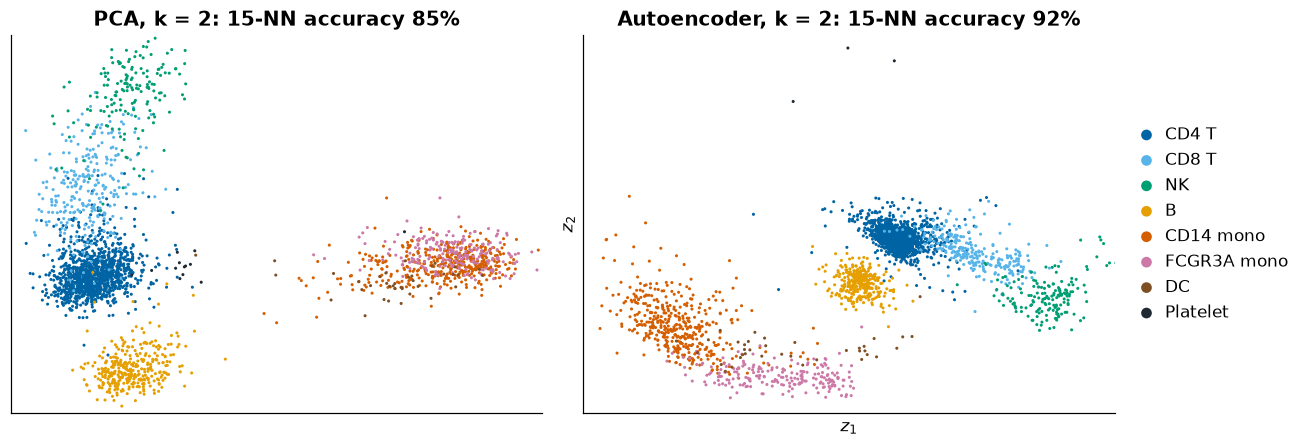

In [10]:
m10, _ = train_ae(X[tr], 10, seed=0)
emb = {}
for k, mk in [(2, models[2]), (10, m10)]:
    _, Z = ae_apply(mk, X)
    Zp = PCA(k, svd_solver="full", random_state=0).fit(X[tr]).transform(X)
    emb[f"ae{k}"], emb[f"pca{k}"] = Z, Zp
acc = {key: eval_embedding(Z[tr], Z[te], ctype[tr], ctype[te]) + eval_embedding(Z[tr], Z[te], leiden[tr], leiden[te])
       for key, Z in emb.items()}
print(pd.DataFrame(acc, index=["15-NN cell type", "probe cell type", "15-NN Leiden", "probe Leiden"]).T.round(3))


def cell_scatter(ax, E, title, legend=False, s=4):
    for c in CTYPES:
        mm = ctype == c
        ax.scatter(E[mm, 0], E[mm, 1], s=s, color=CCOL[c], edgecolor="none", label=c, rasterized=True)
    lo, hi = np.quantile(E, 0.004, 0), np.quantile(E, 0.996, 0)
    r = hi - lo
    ax.set(xlim=(lo[0] - 0.06 * r[0], hi[0] + 0.06 * r[0]), ylim=(lo[1] - 0.06 * r[1], hi[1] + 0.06 * r[1]),
           xticks=[], yticks=[], title=title)
    if legend:
        ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), markerscale=3.5, handletextpad=0.1)


fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
cell_scatter(axes[0], emb["pca2"], f"PCA, k = 2: 15-NN accuracy {100 * acc['pca2'][0]:.0f}%")
cell_scatter(axes[1], emb["ae2"], f"Autoencoder, k = 2: 15-NN accuracy {100 * acc['ae2'][0]:.0f}%", legend=True)
axes[1].set(xlabel="$z_1$", ylabel="$z_2$")
plt.tight_layout(); plt.show()

PCA's two axes mix CD4 T, CD8 T and NK cells; the AE uses its two coordinates more flexibly. The AE axes have no meaning
and no ordering (unlike PC1, PC2), and the code is not unique: another seed gives a rotated, bent version.

At $k = 10$ we visualize each code with UMAP (15 neighbors, min_dist 0.3) — but compute on the code itself.

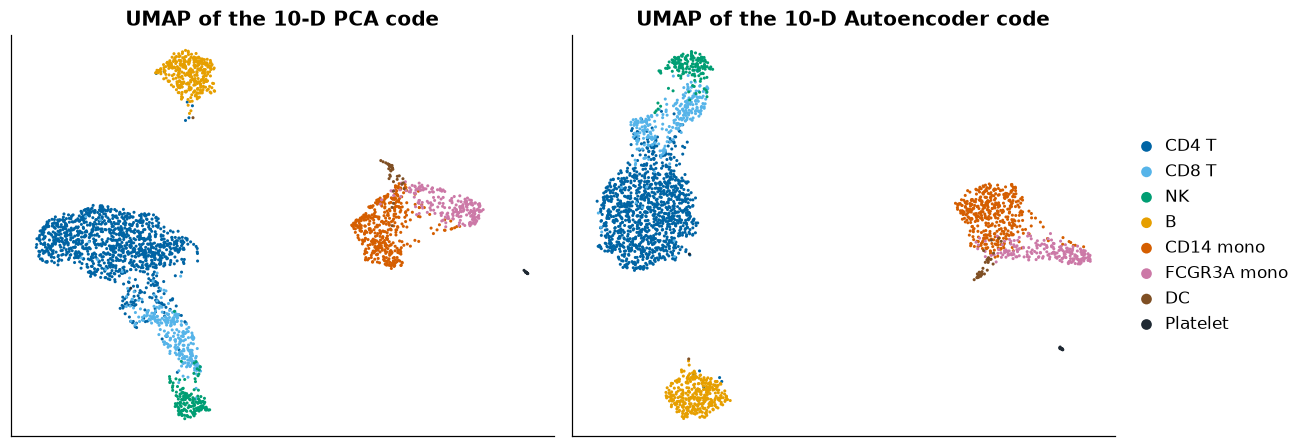

k = 10, 15-NN accuracy on held-out cells: AE 94.3%, PCA 96.4% (all genes: 83.3%)


In [11]:
import umap
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, key, name in [(axes[0], "pca10", "PCA"), (axes[1], "ae10", "Autoencoder")]:
    U2 = umap.UMAP(n_neighbors=15, min_dist=0.3, random_state=0).fit_transform(emb[key])
    cell_scatter(ax, U2, f"UMAP of the 10-D {name} code", legend=(key == "ae10"))
plt.tight_layout(); plt.show()
print(f"k = 10, 15-NN accuracy on held-out cells: AE {100 * acc['ae10'][0]:.1f}%, PCA {100 * acc['pca10'][0]:.1f}% "
      f"(all genes: {100 * raw_acc[0]:.1f}%)")

Both maps separate the same major groups; layout differences are UMAP choices (L15), not biology. Note that the
"identity code" (all genes, perfect reconstruction) transfers labels *worse* than a 10-D code: perfect reconstruction
is not the goal — a compressed code that drops noise is.

## 7. A linear autoencoder learns the PCA subspace

Remove the nonlinearities: $\hat{\mathbf x} = \mathbf W_d\mathbf W_e(\mathbf x - \boldsymbol\mu) + \boldsymbol\mu$.
Baldi & Hornik (1989): at the minimum of the squared error, $\mathbf W_d\mathbf W_e = \mathbf V_k\mathbf V_k^\top$, the
projection onto the top-$k$ principal subspace. We train a linear AE ($k = 10$, full-batch Adam, learning rate
$2\times10^{-3}$, 6,000 steps, all cells) and track the **principal angles** between the column space of
$\mathbf W_d$ and the top-10 principal directions $\mathbf V_{10}$ (0° = same direction, 90° = orthogonal).

**A speed trick that changes nothing.** For a linear AE, $\hat{\mathbf x} = \mathbf A\mathbf x + \mathbf c$ with
$\mathbf A = \mathbf W_d\mathbf W_e$ and $\mathbf c = \mathbf W_d\mathbf b_e + \mathbf b_d$, so the full-batch loss depends on
the data only through the mean $\mathbf m = \frac1n\sum_i\mathbf x_i$ and the second-moment matrix
$\mathbf S_2 = \frac1n\mathbf X^\top\mathbf X$:
$$\mathcal L = \tfrac1d\Big[\operatorname{tr}\mathbf S_2 - 2\operatorname{tr}(\mathbf A\mathbf S_2) + \operatorname{tr}(\mathbf A\mathbf S_2\mathbf A^\top)
  - 2\,\mathbf c^\top(\mathbf m - \mathbf A\mathbf m) + \|\mathbf c\|^2\Big].$$
This is the same loss (and gradient) as `((lin(X)[0] - X) ** 2).mean()`, but each step costs $O(kd^2)$ instead of
passing all $n\times d$ entries through the network: ~6× faster here. We check the equality below.

loss at initialization: direct 0.394886, from moments 0.394886


linear AE: 32 s
linear AE MSE 0.19597 vs PCA (k = 10) 0.19590
principal angles (deg): [ 0.   0.   0.1  0.1  0.1  0.1  0.4  0.7  4.4 26.2]
nine smallest < 4.4 deg; 10th 26 deg;  lambda_10 = 1.486, lambda_11 = 1.458
decoder columns: lengths 3.1-3.9, largest |cosine| between two columns 0.09


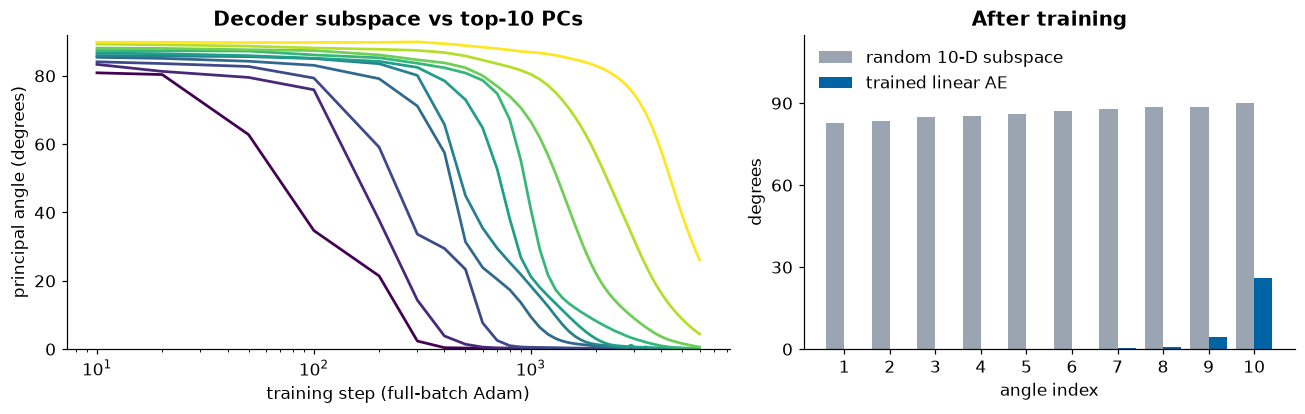

In [12]:
def principal_angles(A, B):
    return np.degrees(np.sort(subspace_angles(A, B)))


mu = X.mean(0)
Xc = X - mu
_, s_, Vt = np.linalg.svd(Xc, full_matrices=False)
Vk = Vt[:K_LIN].T
lam = s_ ** 2 / n
pca_mse = float(((Xc - Xc @ Vk @ Vk.T) ** 2).mean())
X64 = torch.tensor(X, dtype=torch.float64)
S2, m1 = X64.T @ X64 / n, X64.mean(0)


def linear_ae_loss(lin):
    """Full-batch MSE per entry of a linear AE, computed from the mean and second moments of X (float64)."""
    We, be, Wd, bd = (p.double() for p in (lin.enc.weight, lin.enc.bias, lin.dec.weight, lin.dec.bias))
    WeS = We @ S2                                     # k x d
    c = Wd @ be + bd
    val = (torch.trace(S2) - 2 * (WeS * Wd.T).sum() + ((Wd.T @ Wd) * (WeS @ We.T)).sum()
           - 2 * c @ (m1 - Wd @ (We @ m1)) + c @ c)
    return val / d


torch.manual_seed(0)
lin = make_ae(d, K_LIN, linear=True)
with torch.no_grad():
    direct = ((lin(torch.tensor(X))[0] - torch.tensor(X)) ** 2).mean().item()
print(f"loss at initialization: direct {direct:.6f}, from moments {linear_ae_loss(lin).item():.6f}")
opt = torch.optim.Adam(lin.parameters(), lr=2e-3)
log, t = [], time.time()
for it in range(6001):
    loss = linear_ae_loss(lin)
    if it % 100 == 0 or it in (10, 20, 50):
        log.append(dict(it=it, mse=loss.item(), ang=principal_angles(lin.dec.weight.detach().numpy(), Vk)))
    if it == 6000:
        break
    opt.zero_grad(); loss.backward(); opt.step()
print(f"linear AE: {time.time() - t:.0f} s")
ang = log[-1]["ang"]
rand_ang = principal_angles(np.random.default_rng(0).normal(size=(d, K_LIN)), Vk)
print(f"linear AE MSE {log[-1]['mse']:.5f} vs PCA (k = {K_LIN}) {pca_mse:.5f}")
print("principal angles (deg):", np.round(ang, 1))
print(f"nine smallest < {ang[:9].max():.1f} deg; 10th {ang[9]:.0f} deg;  lambda_10 = {lam[9]:.3f}, lambda_11 = {lam[10]:.3f}")
Wd = lin.dec.weight.detach().numpy()
Gm = Wd.T @ Wd
cosm = Gm / np.sqrt(np.outer(np.diag(Gm), np.diag(Gm)))
print(f"decoder columns: lengths {np.sqrt(np.diag(Gm)).min():.1f}-{np.sqrt(np.diag(Gm)).max():.1f}, "
      f"largest |cosine| between two columns {np.abs(cosm - np.eye(K_LIN)).max():.2f}")

its = np.array([l["it"] for l in log]); A = np.array([l["ang"] for l in log])
fig, axes = plt.subplots(1, 2, figsize=(12, 3.9), gridspec_kw=dict(width_ratios=[1.35, 1]))
for j in range(K_LIN):
    axes[0].plot(its[its > 0], A[its > 0, j], color=plt.get_cmap("viridis")(j / (K_LIN - 1)), lw=1.8)
axes[0].set(xscale="log", ylim=(0, 92), xlabel="training step (full-batch Adam)", ylabel="principal angle (degrees)",
            title="Decoder subspace vs top-10 PCs")
x_ = np.arange(1, K_LIN + 1)
axes[1].bar(x_ - 0.2, rand_ang, 0.4, color="#9AA5B1", label="random 10-D subspace")
axes[1].bar(x_ + 0.2, ang, 0.4, color=PALETTE[0], label="trained linear AE")
axes[1].set(xticks=x_, xlabel="angle index", ylabel="degrees", ylim=(0, 115), yticks=[0, 30, 60, 90], title="After training")
axes[1].legend(loc="upper left")
plt.tight_layout(); plt.show()

The reconstruction error matches PCA (difference < 10⁻⁴) and nine of the ten directions line up with the PCs. The 10th
converges slowly because $\lambda_{10}\approx\lambda_{11}$: rotating within that pair barely changes the loss, and flat
directions are slow for gradient descent. A random 10-D subspace of $\mathbb R^{1838}$ is nearly orthogonal to the PCs
(grey). The decoder columns are neither unit length nor orthogonal: the AE finds the **subspace**, not the ordered PCs
($\mathbf W_d\mathbf A$, $\mathbf A^{-1}\mathbf W_e$ fit equally well). Nonlinearity is what an AE adds.

*Slides:* MSE 0.1959 = PCA, nine angles < 4.5°, 10th 26°, λ₁₀ ≈ λ₁₁ (1.49 vs 1.46). The notebook reproduces these
(angles within 0.1°, from float32-vs-float64 arithmetic of the moment-based loss).

## 8. Imputation with a denoising autoencoder

Only about 8% of the entries are nonzero, and many zeros are dropouts. To evaluate imputation we create a known answer:
hide a random 10% of the **nonzero** entries (set them to 0), fit every method on the corrupted matrix only, and score
predictions **only on the hidden entries**. Methods: leave 0; gene mean; PCA rank 10 / 50 reconstruction; mean of the
15 nearest cells (in 20 PCs); a plain AE ($k = 16$); a denoising AE with 30% input masking. The DAE's target is the
corrupted (observed) matrix — it never sees the hidden values.

In [13]:
def impute_benchmark(X, mask_frac=MASK_FRAC, k_ae=K_IMP, seed=0, verbose=True):
    rng_ = np.random.default_rng(seed)
    nz = np.flatnonzero(X > 0)
    hid = rng_.choice(nz, int(mask_frac * len(nz)), replace=False)
    Xo = X.copy().ravel(); Xo[hid] = 0; Xo = Xo.reshape(X.shape)
    truth = X.ravel()[hid]
    preds, recs = {}, {}
    preds["zero (observed)"] = np.zeros_like(truth)
    preds["gene mean"] = np.broadcast_to(Xo.mean(0), X.shape).ravel()[hid]
    for kk in (10, 50):
        p = PCA(kk, svd_solver="full", random_state=0).fit(Xo)
        preds[f"PCA rank {kk}"] = p.inverse_transform(p.transform(Xo)).ravel()[hid]
    Zp = PCA(20, svd_solver="full", random_state=0).fit_transform(Xo)
    idx = NearestNeighbors(n_neighbors=16).fit(Zp).kneighbors(Zp)[1][:, 1:]
    preds["kNN smoothing (15 cells)"] = Xo[idx].mean(1).ravel()[hid]
    for name, mp in [("autoencoder", 0.0), ("denoising AE", 0.3)]:
        m, _ = train_ae(Xo, k_ae, seed=seed, mask_p=mp)
        recs[name] = ae_apply(m, Xo)[0]
        preds[name] = recs[name].ravel()[hid]
    res = pd.DataFrame({name: dict(mse=float(((p_ - truth) ** 2).mean()),
                                   r=float(np.corrcoef(p_, truth)[0, 1]) if p_.std() > 0 else 0.0)
                        for name, p_ in preds.items()}).T
    if verbose:
        print(f"{len(hid):,} of {len(nz):,} nonzero entries hidden ({100 * len(nz) / X.size:.1f}% of entries are nonzero)")
    return res, Xo, recs


t = time.time()
imp, Xobs, recs = impute_benchmark(X)
print(f"imputation benchmark: {time.time() - t:.0f} s")
print(imp.round(3).to_string())

40,874 of 408,743 nonzero entries hidden (8.4% of entries are nonzero)
imputation benchmark: 35 s
                            mse      r
zero (observed)           3.836  0.000
gene mean                 2.412  0.387
PCA rank 10               2.140  0.536
PCA rank 50               2.683  0.368
kNN smoothing (15 cells)  2.153  0.541
autoencoder               2.154  0.542
denoising AE              1.992  0.524


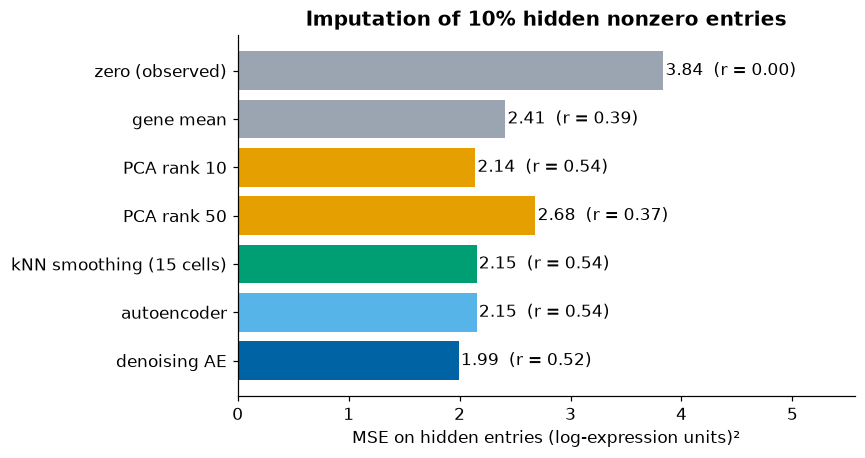

In [14]:
cols = ["#9AA5B1", "#9AA5B1", PALETTE[1], PALETTE[1], PALETTE[2], PALETTE[4], PALETTE[0]]
fig, ax = plt.subplots(figsize=(8, 4.3))
yy = np.arange(len(imp))[::-1]
ax.barh(yy, imp["mse"], color=cols)
for yi, (name, row) in zip(yy, imp.iterrows()):
    ax.text(row.mse + 0.02, yi, f"{row.mse:.2f}  (r = {row.r:.2f})", va="center")
ax.set_yticks(yy, imp.index)
ax.set(xlabel="MSE on hidden entries (log-expression units)²", xlim=(0, imp["mse"].max() * 1.45),
       title=f"Imputation of {int(100 * MASK_FRAC)}% hidden nonzero entries")
plt.tight_layout(); plt.show()

Pooling information across similar cells recovers hidden values: every method that uses a low-dimensional
structure beats "leave 0" and the gene mean by a wide margin. The **denoising AE beats the plain AE**: the plain AE is
trained to reproduce the zeros it sees (including the hidden ones), while masking noise forces it to predict entries
from the rest of the profile — exactly the imputation task. Simple kNN smoothing and PCA are strong baselines; always
include them. r = Pearson correlation between predicted and true values on the hidden entries.

*Slides:* zero 3.84, gene mean 2.41, PCA-10 2.14, kNN 2.15, AE 2.16, denoising AE 1.98. Same masking, seeds and
settings here; the two AE values can differ by ~0.01 because this notebook stops training 50 epochs after the best
validation epoch and runs on a different CPU/thread count (the ranking is unchanged).

## 9. Visualization: imputed values follow cell identity

The B-cell marker MS4A1 on the UMAP of the L15 pipeline: measured values, the model input (10% of nonzeros hidden),
and the denoising-AE output.

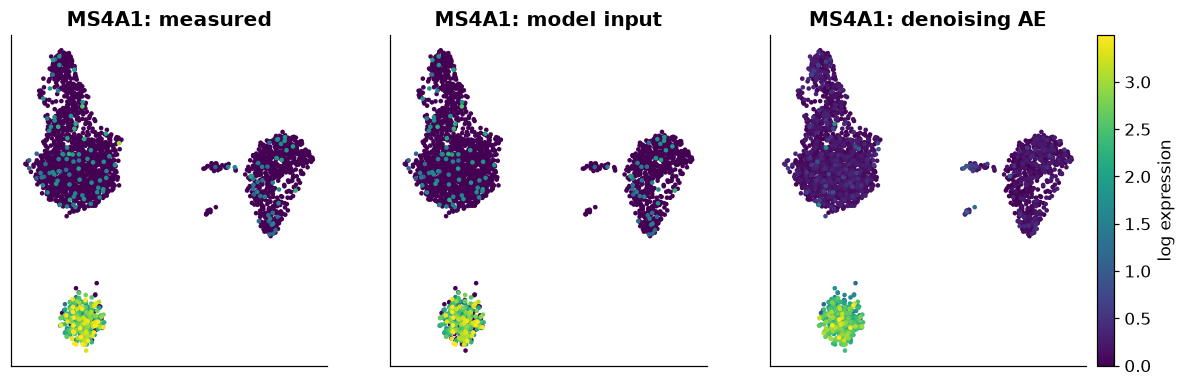

MS4A1 detected in 86% of B cells (75% after hiding); the DAE predicts >= 1.7 for 90% of them


In [15]:
gene = "MS4A1"
gi = list(genes).index(gene)
panels = [("measured", X[:, gi]), ("model input", Xobs[:, gi]), ("denoising AE", recs["denoising AE"][:, gi])]
vmax = np.quantile(X[:, gi], 0.995)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.9))
for ax, (ttl, v) in zip(axes, panels):
    o = np.argsort(v)
    sc_ = ax.scatter(UMAP_L15[o, 0], UMAP_L15[o, 1], c=v[o], s=4, cmap="viridis", vmin=0, vmax=vmax, rasterized=True)
    ax.set(title=f"{gene}: {ttl}", xticks=[], yticks=[])
cb = fig.colorbar(sc_, ax=axes, fraction=0.02, pad=0.01); cb.set_label("log expression")
plt.show()
b = ctype == "B"
print(f"{gene} detected in {100 * (X[b, gi] > 0).mean():.0f}% of B cells ({100 * (Xobs[b, gi] > 0).mean():.0f}% after hiding); "
      f"the DAE predicts >= {np.quantile(recs['denoising AE'][b, gi], 0.1):.1f} for 90% of them")

## 10. Limits: a plain autoencoder has empty latent space

Can we sample a new cell by drawing a random code and decoding it? Draw 5,000 uniform points in the bounding box of the
2-D AE codes and call a point "empty" if it is farther from every cell than 99% of cells are from their nearest neighbor.

44% of the box is empty latent space
distance of a decoded code to the nearest real cell: real cells median 16.0, empty-space codes median 17.2


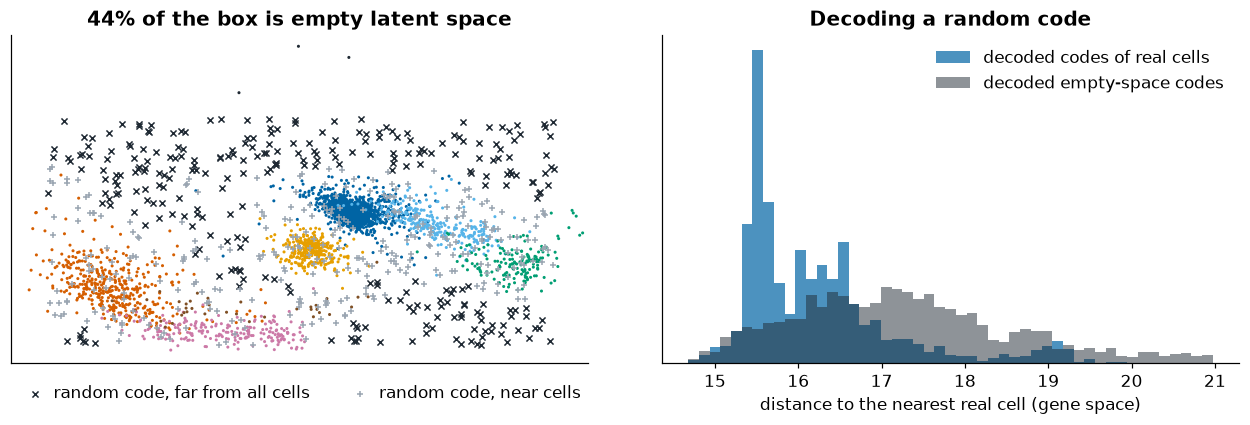

In [16]:
Z2 = emb["ae2"]
nn2 = NearestNeighbors(n_neighbors=2).fit(Z2)
r99 = np.quantile(nn2.kneighbors(Z2)[0][:, 1], 0.99)
Ubox = np.random.default_rng(0).uniform(np.quantile(Z2, 0.005, 0), np.quantile(Z2, 0.995, 0), (5000, 2))
far = nn2.kneighbors(Ubox, n_neighbors=1)[0][:, 0] > r99
with torch.no_grad():
    XU = models[2].dec(torch.tensor(Ubox, dtype=torch.float32)).numpy()
    Xrec = models[2].dec(torch.tensor(Z2, dtype=torch.float32)).numpy()
nng = NearestNeighbors(n_neighbors=1).fit(X)
d_real, d_u = nng.kneighbors(Xrec)[0][:, 0], nng.kneighbors(XU)[0][:, 0]
print(f"{100 * far.mean():.0f}% of the box is empty latent space")
print(f"distance of a decoded code to the nearest real cell: real cells median {np.median(d_real):.1f}, "
      f"empty-space codes median {np.median(d_u[far]):.1f}")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.0))
cell_scatter(axes[0], Z2, f"{100 * far.mean():.0f}% of the box is empty latent space", s=4)
sel = np.arange(600)
h1 = axes[0].scatter(*Ubox[sel][far[sel]].T, s=16, marker="x", color="#1F2933", lw=1, label="random code, far from all cells")
h2 = axes[0].scatter(*Ubox[sel][~far[sel]].T, s=16, marker="+", color="#9AA5B1", lw=1, label="random code, near cells")
axes[0].legend(handles=[h1, h2], loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=2, handletextpad=0.1)
bins = np.linspace(np.quantile(np.r_[d_real, d_u], 0.002), np.quantile(np.r_[d_real, d_u], 0.995), 50)
axes[1].hist(d_real, bins=bins, color=PALETTE[0], alpha=0.7, density=True, label="decoded codes of real cells")
axes[1].hist(d_u[far], bins=bins, color="#1F2933", alpha=0.5, density=True, label="decoded empty-space codes")
axes[1].set(xlabel="distance to the nearest real cell (gene space)", yticks=[], title="Decoding a random code")
axes[1].legend(loc="upper right")
plt.tight_layout(); plt.show()

A plain AE defines no density on $\mathbf z$: there is no rule for which codes are "valid", and decoding a code from
an empty region produces a profile unlike any real cell. A variational autoencoder (L18) fixes this by imposing a
prior $p(\mathbf z)$ on the latent space.

## 11. (Optional, GPU/MPS) Convolutional autoencoder on BloodMNIST

The same idea for images: conv 3→32 (stride 1), 32→64 (stride 2), 64→128 (stride 2), linear 6272→32 = $\mathbf z$, and a
transposed-convolution decoder with a sigmoid output (pixels in [0, 1]). 25 epochs of Adam on the 11,959 training
images, compared with PCA with 32 components; then a denoising version trained on inputs with Gaussian noise
(σ = 0.15). Data: BloodMNIST, MedMNIST v2 (Yang et al., *Scientific Data* 2023; CC BY 4.0), 28 × 28 blood-cell
microscopy images (Acevedo et al. 2020). Runs only when `RUN_CONV` is true (GPU/MPS); about 1 minute on a GPU,
too slow for this notebook's CPU budget. The executed copy ran it on an NVIDIA GPU (≈ 50 s): test MSE 0.0038
(conv AE, 665,763 parameters) vs 0.0047 (PCA, 32 components), linear-probe accuracy 74.6% vs 75.3%, and
denoising 0.0187 (noisy input) → 0.0042 (DAE output).

                   test_mse    params  seconds   probe  noisy_input_mse
conv AE              0.0038  665763.0  22.9972  0.7463              NaN
denoising conv AE    0.0042  665763.0  25.4520     NaN           0.0187
PCA (32)             0.0047       NaN      NaN  0.7533              NaN


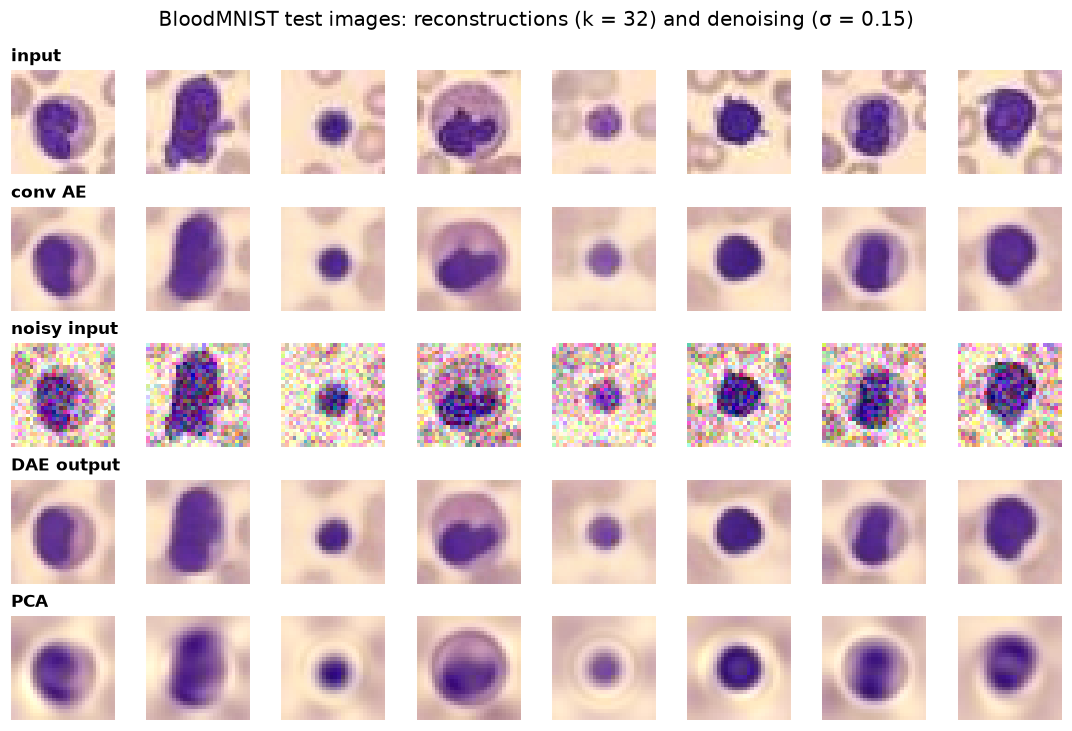

In [17]:
if RUN_CONV:
    from medmnist import BloodMNIST

    def blood(split):
        ds = BloodMNIST(split=split, download=True, root=str(DATA))
        return (ds.imgs.astype(np.float32) / 255).transpose(0, 3, 1, 2), ds.labels[:, 0]

    def conv_ae(k=32):
        class CAE(nn.Module):
            def __init__(self):
                super().__init__()
                self.enc = nn.Sequential(nn.Conv2d(3, 32, 3, 1, 1), nn.ReLU(), nn.Conv2d(32, 64, 3, 2, 1), nn.ReLU(),
                                         nn.Conv2d(64, 128, 3, 2, 1), nn.ReLU(), nn.Flatten(), nn.Linear(128 * 7 * 7, k))
                self.dec = nn.Sequential(nn.Linear(k, 128 * 7 * 7), nn.ReLU(), nn.Unflatten(1, (128, 7, 7)),
                                         nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
                                         nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),
                                         nn.Conv2d(32, 3, 3, 1, 1), nn.Sigmoid())

            def forward(self, x):
                z = self.enc(x)
                return self.dec(z), z
        return CAE()

    Btr, bytr = blood("train"); Bte, byte = blood("test")
    show = np.random.default_rng(3).choice(len(Bte), 8, replace=False)
    Bn = np.clip(Bte + np.random.default_rng(5).normal(0, 0.15, Bte.shape).astype(np.float32), 0, 1)
    conv_res, rows_img = {}, {"input": Bte[show]}
    for name, sigma in [("conv AE", 0.0), ("denoising conv AE", 0.15)]:
        torch.manual_seed(0)
        cm = conv_ae(32).to(dev)
        copt = torch.optim.Adam(cm.parameters(), lr=1e-3)
        Bt = torch.tensor(Btr)
        t = time.time()
        for ep in range(25):
            perm = torch.randperm(len(Bt))
            for i in range(0, len(Bt), 128):
                xb = Bt[perm[i:i + 128]].to(dev)
                xin = (xb + sigma * torch.randn_like(xb)).clamp(0, 1) if sigma > 0 else xb
                l_ = ((cm(xin)[0] - xb) ** 2).mean()
                copt.zero_grad(); l_.backward(); copt.step()
        cm.eval()
        with torch.no_grad():
            src = Bn if sigma > 0 else Bte
            out = [cm(torch.tensor(src[i:i + 1000]).to(dev)) for i in range(0, len(src), 1000)]
        rec = np.concatenate([o[0].cpu().numpy() for o in out])
        conv_res[name] = dict(test_mse=float(((rec - Bte) ** 2).mean()), params=n_params(cm), seconds=time.time() - t)
        rows_img["noisy input" if sigma > 0 else "conv AE"] = (Bn if sigma > 0 else rec)[show]
        if sigma > 0:
            rows_img["DAE output"] = rec[show]
            conv_res[name]["noisy_input_mse"] = float(((Bn - Bte) ** 2).mean())
        else:
            with torch.no_grad():
                ztr = np.concatenate([cm(torch.tensor(Btr[i:i + 1000]).to(dev))[1].cpu().numpy() for i in range(0, len(Btr), 1000)])
            zte = np.concatenate([o[1].cpu().numpy() for o in out])
            s = StandardScaler().fit(ztr)
            conv_res[name]["probe"] = LogisticRegression(max_iter=3000).fit(s.transform(ztr), bytr).score(s.transform(zte), byte)
    p = PCA(32, svd_solver="randomized", random_state=0).fit(Btr.reshape(len(Btr), -1))
    Zptr, Zpte = p.transform(Btr.reshape(len(Btr), -1)), p.transform(Bte.reshape(len(Bte), -1))
    rec_p = p.inverse_transform(Zpte).reshape(Bte.shape)
    s = StandardScaler().fit(Zptr)
    conv_res["PCA (32)"] = dict(test_mse=float(((rec_p - Bte) ** 2).mean()),
                                probe=LogisticRegression(max_iter=3000).fit(s.transform(Zptr), bytr).score(s.transform(Zpte), byte))
    rows_img["PCA"] = np.clip(rec_p[show], 0, 1)
    print(pd.DataFrame(conv_res).T.round(4).to_string())
    fig, axes = plt.subplots(len(rows_img), 8, figsize=(10, 1.35 * len(rows_img)))
    for r_, (lab, ims) in enumerate(rows_img.items()):
        for c_ in range(8):
            axes[r_, c_].imshow(ims[c_].transpose(1, 2, 0)); axes[r_, c_].axis("off")
        axes[r_, 0].set_title(lab, loc="left", fontsize=11)
    plt.suptitle("BloodMNIST test images: reconstructions (k = 32) and denoising (σ = 0.15)")
    plt.tight_layout(); plt.show()
else:
    print("RUN_CONV is False (no GPU/MPS): skipping the BloodMNIST convolutional autoencoder.")

## 12. Biological interpretation

- **What the code captures.** With $k = 2$ the AE separates B cells, NK cells, CD8 T cells and both monocyte types
  better than the first two PCs; with $k \ge 8$ a linear code (PCA) already carries the cell-type structure, and the
  extra flexibility of the AE buys nothing on 2,000 cells. Major PBMC populations differ along a few strong programs
  (T/NK cytotoxicity, B-cell receptor, myeloid genes), which PCA captures well.
- **Imputation is smoothing.** The DAE output for MS4A1 is high in (almost) every B cell and near zero elsewhere:
  it borrows strength from similar cells. That helps visualization and hypothesis generation but can **create
  signal** — imputed values are not measurements. Never run differential-expression tests or gene–gene correlations
  on imputed values; test on raw counts with a count model.
- **Caveats of the benchmark.** Real dropouts are not uniformly random (they hit lowly expressed genes more), and a
  method that predicts positive values everywhere is rewarded on hidden nonzeros but would also "impute" expression
  into genuine zeros. Labels come from a PCA-based pipeline, which favors PCA.
- Dedicated tools (DCA with a negative binomial loss, DeepImpute, scVI in L18) use count likelihoods, batch covariates
  and much larger data sets.

In [18]:
print(f"total runtime: {(time.time() - T0) / 60:.1f} min")

total runtime: 4.6 min


## Try it yourself

The cell below contains ready-made switches for the first three items (set one to `True` and run the cell).

1. **Train with a Poisson loss on raw counts (CS284A).** Keep the log-normalized input, but let the decoder output a
   log rate per 10,000 UMIs, $\eta_{ij} = g_{\theta}(\mathbf z_i)_j + \log(\text{library}_i/10^4)$, and minimize
   $\sum_j e^{\eta_{ij}} - y_{ij}\eta_{ij}$ on the raw counts $y_{ij}$ (`loss="poisson"`). Compare the 15-NN accuracy of
   its code with the MSE autoencoder at the same $k$. Why does the offset matter?
2. **Add an L1 penalty on z with k = 256. Are codes sparse?** (`l1=` in `train_ae`.) An overcomplete code ($k > $ hidden
   width) can copy; count the fraction of near-zero code entries and the number of units that are ever active.
3. **Mask 30% instead of 10%. Which method degrades most?** (`impute_benchmark(X, mask_frac=0.3)`.)
4. Set `SEEDS = [0, 1, 2]` and `PATIENCE = None` in the first code cell and rerun the sweep: how large is the
   seed-to-seed spread, and does it change any conclusion?
5. Train the denoising AE with `mask_p` = 0.1, 0.5, 0.7 in `impute_benchmark`. Is there an optimal corruption level?
6. (CS284A) Recover the ordered, orthonormal principal components from the trained linear AE of §7: take the SVD of
   $\mathbf W_d$ and compare its left singular vectors with $\mathbf V_{10}$ (Plaut 2018). Which ones match best?

In [19]:
TRY_POISSON = False   # item 1
TRY_SPARSE = False    # item 2
TRY_MASK30 = False    # item 3

if TRY_POISSON:
    off = np.log(lib / 1e4)
    mp_, hp_ = train_ae(X[tr], 16, seed=0, loss="poisson", Y=Xcounts[tr], offset=off[tr])
    mse_, _ = train_ae(X[tr], 16, seed=0)
    for name, mk in [("Poisson AE", mp_), ("MSE AE", mse_)]:
        _, Ztr_ = ae_apply(mk, X[tr]); _, Zte_ = ae_apply(mk, X[te])
        print(f"{name} (k = 16): 15-NN {eval_embedding(Ztr_, Zte_, ctype[tr], ctype[te])[0]:.3f}")

if TRY_SPARSE:
    for l1 in (0.0, 1e-3, 1e-2):
        ms_, _ = train_ae(X[tr], 256, seed=0, l1=l1)
        _, Zs = ae_apply(ms_, X[te])
        print(f"L1 = {l1:g}: {100 * (np.abs(Zs) < 1e-2).mean():.0f}% of code entries |z| < 0.01; "
              f"{(np.abs(Zs) > 1e-2).any(0).sum()} of 256 units ever active; mean |z| {np.abs(Zs).mean():.3f}")

if TRY_MASK30:
    imp30, _, _ = impute_benchmark(X, mask_frac=0.3)
    print(pd.DataFrame({"MSE, 10% hidden": imp["mse"], "MSE, 30% hidden": imp30["mse"]}).round(3).to_string())